In [1]:
from pathlib import Path
from mhdr.dataloader.process_multilabel_human_data import load_multilabel_human_data
from mhdr.dataloader.io import read_csv
import pandas as pd
import os
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"
DATA = read_csv(INPUT_DIR / "questions_master.csv")
DIMENSIONS = [
    "Emotional",
    "Environmental",
    "Financial",
    "Intellectual",
    "Occupational",
    "Physical",
    "Social",
    "Spiritual",
]

In [2]:
HUMAN_DATA = load_multilabel_human_data(INPUT_DIR, [DATA])
print(len(HUMAN_DATA))
HUMAN_DATA.head()


3480


,qid,text,Emotional,Environmental,Financial,Intellectual,Occupational,Physical,Social,Spiritual
0,CD_RISC_1,I am able to adapt when changes occur.,2,0,0,1,0,0,0,0
1,CD_RISC_1,I am able to adapt when changes occur.,3,0,0,1,0,0,0,2
2,CD_RISC_1,I am able to adapt when changes occur.,1,0,0,0,0,0,3,2
3,CD_RISC_1,I am able to adapt when changes occur.,3,1,0,0,0,0,0,2
4,CD_RISC_1,I am able to adapt when changes occur.,0,3,0,1,0,0,2,0


In [3]:
from sklearn.model_selection import train_test_split
import tempfile
from pathlib import Path


def split_by_qid(df):

    qids = df["qid"].unique()

    train_qid, temp_qid = train_test_split(
        qids,
        test_size=0.3,
        random_state=42
    )

    val_qid, test_qid = train_test_split(
        temp_qid,
        test_size=0.5,
        random_state=42
    )

    train_df = df[df["qid"].isin(train_qid)]
    val_df   = df[df["qid"].isin(val_qid)]
    test_df  = df[df["qid"].isin(test_qid)]

    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_qid(HUMAN_DATA)

train_df.to_csv(TEMP_DIR / "train.csv", index=False)
val_df.to_csv(TEMP_DIR / "val.csv", index=False)
test_df.to_csv(TEMP_DIR / "test.csv", index=False)

In [4]:
from mhdr.classifier.linear import HumanRankClassifier
clf = HumanRankClassifier(
    dimensions=DIMENSIONS,
    alpha=1.0,
    beta=2.0,
    margin=0.5,
)

/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 916.16it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
search_path = TEMP_DIR / "hyperparam_search_results.csv"

if os.path.exists(search_path):
    print("Loading cached hyperparameter search results...")
    search_df = pd.read_csv(search_path)
else:
    print("Running hyperparameter search...")
    
    search_df = clf.search_train_hyperparams(
        train_df=train_df,
        val_df=val_df,
        alpha_list=[1.0],
        beta_list=[1.5, 2, 3, 4, 5, 6],
        lr_list=[2e-4, 1e-4, 7e-5],
        margin_list=[0.15, 0.2, 0.25],
        epochs=20,
        batch_size=16,
        text_col="text",
    )

    search_df.to_csv(search_path, index=False)

best_row = search_df.iloc[0]

print(search_df.head())
print("\nBest hyperparams:")
print(best_row)

Loading cached hyperparameter search results...
   alpha  beta       lr  margin  val_loss   val_bce  val_rank
0    1.0   1.5  0.00020    0.15  0.796757  0.625691  0.114142
1    1.0   1.5  0.00010    0.15  0.813869  0.642462  0.114210
2    1.0   1.5  0.00007    0.15  0.818406  0.648599  0.112879
3    1.0   1.5  0.00020    0.20  0.850324  0.618871  0.154132
4    1.0   1.5  0.00010    0.20  0.864652  0.638071  0.150710

Best hyperparams:
alpha       1.000000
beta        1.500000
lr          0.000200
margin      0.150000
val_loss    0.796757
val_bce     0.625691
val_rank    0.114142
Name: 0, dtype: float64


In [6]:
best_clf = HumanRankClassifier(
    dimensions=DIMENSIONS,
    alpha=float(best_row["alpha"]),
    beta=float(best_row["beta"]),
    margin=float(best_row["margin"]),
)

best_clf.fit(
    train_df=train_df,
    val_df=val_df,
    epochs=20,
    batch_size=16,
    lr=float(best_row["lr"]),
    text_col="text",
)

human_train = best_clf.evaluate_human_baseline_loss(train_df)
human_val = best_clf.evaluate_human_baseline_loss(val_df)
human_test = best_clf.evaluate_human_baseline_loss(test_df)

print("human train:", human_train)
print("human val:", human_val)
print("human test:", human_test)

th_df = best_clf.search_best_threshold(val_df=val_df, text_col="text")
print(th_df.head())

best_threshold = float(th_df.iloc[0]["threshold"])
print(best_threshold)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1733.16it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 77/77 [00:01<00:00, 39.80it/s]


Epoch 1/20 | train_loss=0.8846 (bce=0.6842, rank=0.1342, pairs=11167) | val_loss=0.8533 (bce=0.6781, rank=0.1175, pairs=2323)
Epoch 2/20 | train_loss=0.8501 (bce=0.6731, rank=0.1191, pairs=11167) | val_loss=0.8412 (bce=0.6711, rank=0.1139, pairs=2323)
Epoch 3/20 | train_loss=0.8345 (bce=0.6663, rank=0.1145, pairs=11167) | val_loss=0.8338 (bce=0.6657, rank=0.1124, pairs=2323)
Epoch 4/20 | train_loss=0.8229 (bce=0.6612, rank=0.1114, pairs=11167) | val_loss=0.8295 (bce=0.6610, rank=0.1127, pairs=2323)
Epoch 5/20 | train_loss=0.8186 (bce=0.6564, rank=0.1097, pairs=11167) | val_loss=0.8255 (bce=0.6575, rank=0.1125, pairs=2323)
Epoch 6/20 | train_loss=0.8103 (bce=0.6524, rank=0.1085, pairs=11167) | val_loss=0.8218 (bce=0.6537, rank=0.1127, pairs=2323)
Epoch 7/20 | train_loss=0.8087 (bce=0.6491, rank=0.1073, pairs=11167) | val_loss=0.8192 (bce=0.6506, rank=0.1132, pairs=2323)
Epoch 8/20 | train_loss=0.8006 (bce=0.6459, rank=0.1066, pairs=11167) | val_loss=0.8163 (bce=0.6475, rank=0.1133, pair

In [7]:
val_loss = best_clf.evaluate_loss(val_df)
test_loss = best_clf.evaluate_loss(test_df)

print("val_loss =", val_loss)
print("test_loss =", test_loss)

val_loss = {'loss': 0.8013238676206362, 'bce': 0.6261269365690677, 'rank': 0.11690464716531365, 'n_pairs': 2323}
test_loss = {'loss': 0.8183843986193339, 'bce': 0.635179424512954, 'rank': 0.1223596282763848, 'n_pairs': 2443}


In [8]:
val_l1 = best_clf.evaluate_postprocess_l1(
    df=val_df,
    text_col="text",
    threshold=best_threshold,
)

test_l1 = best_clf.evaluate_postprocess_l1(
    df=test_df,
    text_col="text",
    threshold=best_threshold,
)

print("val_l1 =", val_l1)
print("test_l1 =", test_l1)

val_l1 = 6.611111
test_l1 = 6.855238


In [9]:
post_df = best_clf.search_best_postprocess(
    val_df=val_df,
    text_col="text",
    thresholds=[0.40, 0.43, 0.45, 0.47, 0.50, 0.55],
    gap_thresholds=[0.01, 0.03, 0.05, 0.07, 0.10, 0.15],
)

print(post_df.head(20))
best_post = post_df.iloc[0]
print(best_post)

val_l1 = best_clf.evaluate_postprocess_l1(
    df=val_df,
    text_col="text",
    method="threshold_gap",
    threshold=float(best_post["threshold"]),
    gap_threshold=float(best_post["gap_threshold"]),
)

           method  threshold  gap_threshold    val_l1
0   threshold_gap       0.47           0.05  6.538314
1   threshold_gap       0.47           0.07  6.538314
2   threshold_gap       0.47           0.10  6.538314
3   threshold_gap       0.47           0.15  6.538314
4   threshold_gap       0.45           0.05  6.559387
5   threshold_gap       0.45           0.15  6.559387
6   threshold_gap       0.45           0.10  6.559387
7   threshold_gap       0.45           0.07  6.559387
8   threshold_gap       0.50           0.05  6.599617
9   threshold_gap       0.50           0.10  6.599617
10  threshold_gap       0.50           0.01  6.599617
11  threshold_gap       0.50           0.15  6.599617
12  threshold_gap       0.55           0.01  6.599617
13  threshold_gap       0.55           0.03  6.599617
14  threshold_gap       0.55           0.05  6.599617
15  threshold_gap       0.47           0.03  6.599617
16  threshold_gap       0.47           0.01  6.599617
17  threshold_gap       0.55

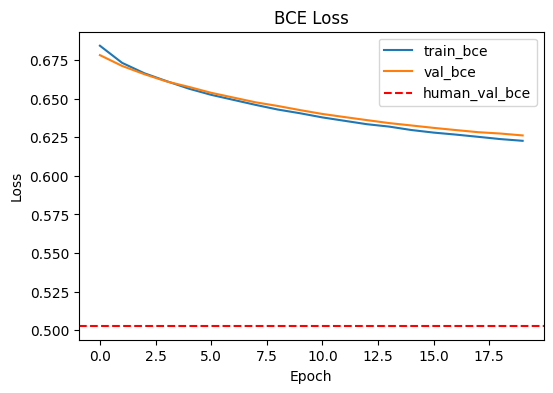

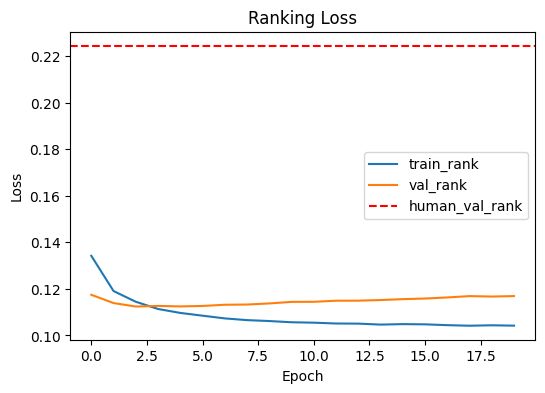

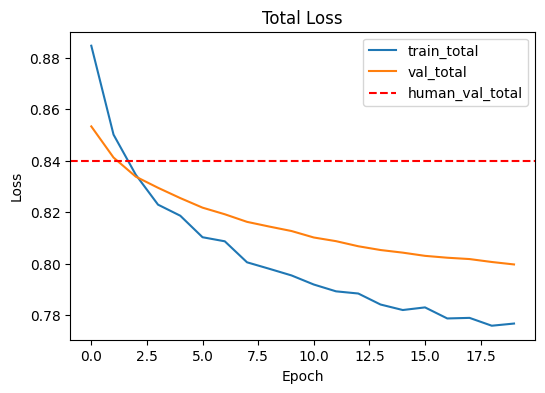

In [10]:
import matplotlib.pyplot as plt

train_bce = [x["bce"] for x in best_clf.train_losses]
val_bce = [x["bce"] for x in best_clf.val_losses]

plt.figure(figsize=(6,4))
plt.plot(train_bce, label="train_bce")
plt.plot(val_bce, label="val_bce")

plt.axhline(human_val["bce"], linestyle="--", color="red", label="human_val_bce")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BCE Loss")
plt.legend()
plt.show()

train_rank = [x["rank"] for x in best_clf.train_losses]
val_rank = [x["rank"] for x in best_clf.val_losses]

plt.figure(figsize=(6,4))
plt.plot(train_rank, label="train_rank")
plt.plot(val_rank, label="val_rank")

plt.axhline(human_val["rank"], linestyle="--", color="red", label="human_val_rank")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ranking Loss")
plt.legend()
plt.show()

train_total = [x["loss"] for x in best_clf.train_losses]
val_total = [x["loss"] for x in best_clf.val_losses]

plt.figure(figsize=(6,4))
plt.plot(train_total, label="train_total")
plt.plot(val_total, label="val_total")

plt.axhline(human_val["loss"], linestyle="--", color="red", label="human_val_total")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

In [11]:
# import matplotlib.pyplot as plt

# train_bce = [x["bce"] for x in clf.train_losses]
# test_bce = test_loss["bce"]

# plt.figure(figsize=(6,4))
# plt.plot(train_bce, label="train_bce")

# plt.axhline(test_bce, linestyle="-", color="green", label="test_bce")
# plt.axhline(human_test["bce"], linestyle="--", color="red", label="human_test_bce")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("BCE Loss (Test)")
# plt.legend()
# plt.show()

# train_rank = [x["rank"] for x in clf.train_losses]
# test_rank = test_loss["rank"]

# plt.figure(figsize=(6,4))
# plt.plot(train_rank, label="train_rank")

# plt.axhline(test_rank, linestyle="-", color="green", label="test_rank")
# plt.axhline(human_test["rank"], linestyle="--", color="red", label="human_test_rank")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Ranking Loss (Test)")
# plt.legend()
# plt.show()

# train_total = [x["loss"] for x in clf.train_losses]
# test_total = test_loss["loss"]

# plt.figure(figsize=(6,4))
# plt.plot(train_total, label="train_total")

# plt.axhline(test_total, linestyle="-", color="green", label="test_total")
# plt.axhline(human_test["loss"], linestyle="--", color="red", label="human_test_total")

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Total Loss (Test)")
# plt.legend()
# plt.show()


In [ ]:
import numpy as np
import pandas as pd

test_items = [
    ("TEST_1", "I feel disconnected from my friends."),
    ("TEST_2", "I feel overwhelmed by my emotions."),
    ("TEST_3", "My body feels tired and drained."),
    ("TEST_4", "I worry about my financial future."),
    ("TEST_5", "I enjoy challenging my mind with new ideas."),
    ("TEST_6", "My life feels connected to a deeper purpose."),
    ("TEST_7", "My living environment makes me uncomfortable."),
    ("TEST_8", "I have to act on a hunch"),
]

rows = []

for qid, text in test_items:
    scores = best_clf.predict_scores([text])[0]

    row = {
        "qid": qid,
        "text": text,
    }

    row.update(
        best_clf.scores_to_ranked_vector(
            scores=scores,
            dimensions=DIMENSIONS,
            threshold=best_threshold, 
        )
    )

    rows.append(row)

pred_df = pd.DataFrame(rows)
pred_df = pred_df[["qid", "text"] + DIMENSIONS]

print(pred_df)

      qid                                           text  Emotional  \
0  TEST_1           I feel disconnected from my friends.          2   
1  TEST_2             I feel overwhelmed by my emotions.          1   
2  TEST_3               My body feels tired and drained.          3   
3  TEST_4             I worry about my financial future.          1   
4  TEST_5    I enjoy challenging my mind with new ideas.          2   
5  TEST_6   My life feels connected to a deeper purpose.          0   
6  TEST_7  My living environment makes me uncomfortable.          1   
7  TEST_8                       I have to act on a hunch          1   

   Environmental  Financial  Intellectual  Occupational  Physical  Social  \
0              0          0             0             0         0       1   
1              0          0             0             0         0       0   
2              0          0             0             0         2       1   
3              0          0             0           